In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as torch_F
import torch.optim as optim
from torchcfm.conditional_flow_matching import ExactOptimalTransportConditionalFlowMatcher, VariancePreservingConditionalFlowMatcher
from torchdiffeq import odeint
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, TensorDataset

device = "mps" if torch.backends.mps.is_available() else "cpu"

# --- [1. Configuration] ---
d = 3               
K = 150              
M_per_dim = 4 * K + 2
M_total = d * M_per_dim
n_dataset = 10000
num_epochs = 1500
batch_size = 128
lr = 1e-4

# --- [2. Multidimensional Fourier Functions] ---

def path_encoding_multidim(increments, t_points, K, T):
    d_size = increments.shape[1]
    omega0 = 2 * np.pi / T
    freq_indices = np.arange(-K, K + 1)
    all_dims_real = []
    for i in range(d_size):
        inc = increments[:, i]
        coeffs = [np.sum(np.exp(-1j * k * omega0 * t_points) * inc) for k in freq_indices]
        coeffs = np.array(coeffs)
        real_flat = np.concatenate([np.real(coeffs), np.imag(coeffs)])
        all_dims_real.append(real_flat)
    return np.concatenate(all_dims_real)

def path_decoding_multidim(vector_flat, t_points, T, d, K, target_qv=1.0):
    omega0 = 2 * np.pi / T
    N_points = len(t_points)
    dt = T / (N_points - 1)
    K_max = (N_points - 1) // 2 
    
    N_coeffs_low = 2 * K + 1
    M_per_dim_low = 4 * K + 2
    reconstructed_path = np.zeros((N_points, d))

    # see  II.4 Roughness and High-Frequency Augmentation

    for i in range(d):
        # 'skeleton'
        segment = vector_flat[i * M_per_dim_low : (i + 1) * M_per_dim_low]
        coeffs_low = segment[:N_coeffs_low] + 1j * segment[N_coeffs_low:]
        
        # full spectrum
        full_freqs = np.arange(-K_max, K_max + 1)
        full_coeffs = np.zeros(len(full_freqs), dtype=complex)
        mid = K_max
        full_coeffs[mid-K : mid+K+1] = coeffs_low
        noise_var = target_qv / (2 * K_max + 1) 
        noise_std = np.sqrt(noise_var)

        # Fill the gaps
        for idx, k in enumerate(full_freqs):
            if abs(k) > K:
                full_coeffs[idx] = (np.random.normal(0, noise_std) + 
                                    1j * np.random.normal(0, noise_std)) * omega0 * 0.02 * k

        # Integrate to Path Space
        recon = np.zeros(N_points, dtype=complex)
        for idx, k in enumerate(full_freqs):
            val = full_coeffs[idx]
            if k == 0:
                recon += val * t_points / T
            else:
                recon += val * (np.exp(1j * k * omega0 * t_points) - 1) / (1j * k * omega0)
        
        reconstructed_path[:, i] = np.real(recon)
        
    return reconstructed_path

# --- [OU Specific Parameters] ---
theta_ou = 1.0      # Speed of mean reversion
mu_ou = 0.25         # Long-term mean
sigma_ou = 0.2      # Volatility
x0_ou = 0.0         # Starting value

# --- [3. Data Generation: OU Paths] ---
T_bm, N_bm = 1.0, 1000
dt = T_bm / N_bm
t_inc = np.linspace(dt, T_bm, N_bm)
t_path = np.linspace(0, T_bm, N_bm + 1)

all_F_raw = []

print(f"Generating {n_dataset} unique OU process paths...")
for _ in range(n_dataset):
    x_curr = np.full((d,), x0_ou)
    path_increments = np.zeros((N_bm, d))
    
    for t_step in range(N_bm):
        dW = np.random.normal(0, np.sqrt(dt), size=d)
        
        # OU SDE: dx = theta * (mu - x) * dt + sigma * dW
        dx = theta_ou * (mu_ou - x_curr) * dt + sigma_ou * dW
        
        path_increments[t_step, :] = dx
        x_curr += dx

    f_encoded = path_encoding_multidim(path_increments, t_inc, K, T_bm)
    all_F_raw.append(f_encoded)

F_tensor_raw = torch.tensor(np.array(all_F_raw), dtype=torch.float32, device=device)

mu_f, sigma_f = F_tensor_raw.mean(), F_tensor_raw.std()
F_target_norm = (F_tensor_raw - mu_f) / sigma_f

dataset = TensorDataset(F_target_norm) 
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --- [4. Model Architecture] ---

class LearnableTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(1, dim), nn.ReLU(), nn.Linear(dim, dim))
    def forward(self, t): return self.mlp(t)

class FlowNetTransformerToken(nn.Module):
    def __init__(self, features_per_dim, num_dims, num_layers=4, num_heads=8, hidden_dim=512):
        super().__init__()
        self.f_dim = features_per_dim
        self.num_dims = num_dims
        self.input_proj = nn.Linear(features_per_dim, hidden_dim)
        self.t_embed = LearnableTimeEmbedding(hidden_dim)
        
        self.dim_embed = nn.Parameter(torch.randn(1, num_dims, hidden_dim))
        
        layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads, 
                                           dim_feedforward=hidden_dim*4, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.output_proj = nn.Linear(hidden_dim, features_per_dim)

    def forward(self, t, x):
        batch_size = x.shape[0]
        x = x.view(batch_size, self.num_dims, self.f_dim)
        h = self.input_proj(x)
        h = h + self.t_embed(t.view(-1, 1)).unsqueeze(1)
        h = h + self.dim_embed
        h = self.transformer(h)
        return self.output_proj(h).view(batch_size, -1)

model = FlowNetTransformerToken(M_per_dim, num_dims=d).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
cfm_utils = VariancePreservingConditionalFlowMatcher(sigma=0.01)

# --- [5. Training] ---
model.train()
for epoch in tqdm(range(num_epochs)):
    for batch in dataloader:
        x_1 = batch[0].to(device)
        x_0 = torch.randn_like(x_1)
        t, x_t, u_t = cfm_utils.sample_location_and_conditional_flow(x_0, x_1)
        v_t = model(t, x_t)
        loss = torch_F.mse_loss(v_t, u_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# --- [6. Inference] ---
def decode_flow_torch(model, x_noised, steps=100):
    model.eval()
    with torch.no_grad():
        def ode_func(t, x):
            t_vec = torch.ones(x.shape[0], 1, device=device) * t
            return model(t_vec, x)
        t_span = torch.linspace(0, 1, steps, device=device)
        return odeint(ode_func, x_noised, t_span, method='rk4')[-1]

n_samples = 100 
z0_batch = torch.randn(n_samples, M_total).to(device)

print(f"Generating {n_samples} samples via ODE solver...")
generated_F_batch = decode_flow_torch(model, z0_batch)
generated_F_unnorm = (generated_F_batch * sigma_f + mu_f).detach().cpu().numpy()
all_W_gen = np.array([path_decoding_multidim(generated_F_unnorm[i], t_path, T_bm, d, K, target_qv = sigma_ou**2) 
                     for i in range(n_samples)])

Generating 10000 unique OU process paths...


  0%|          | 0/1500 [00:00<?, ?it/s]

Generating 100 samples via ODE solver...


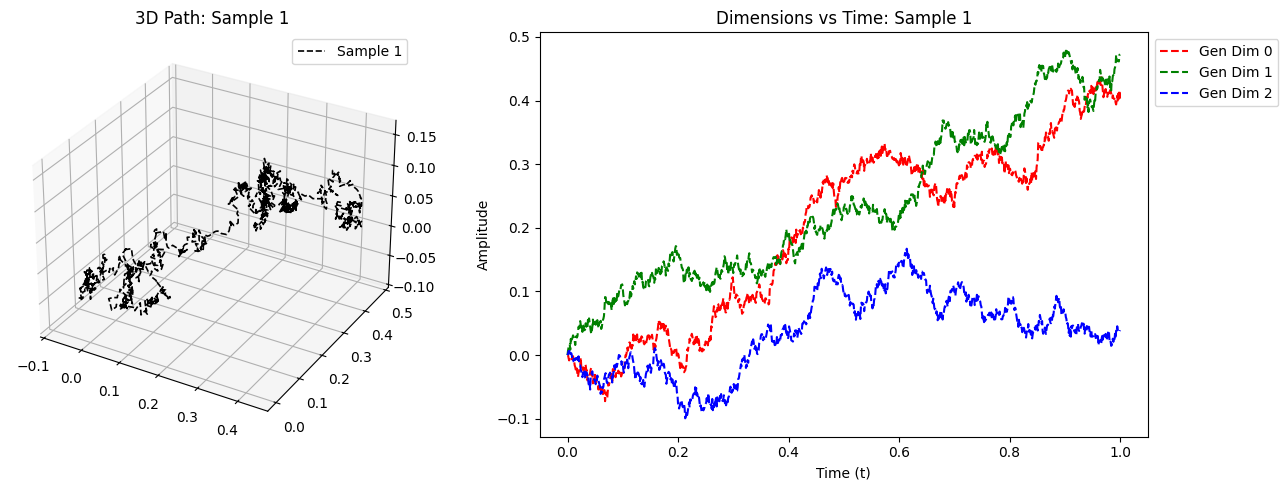

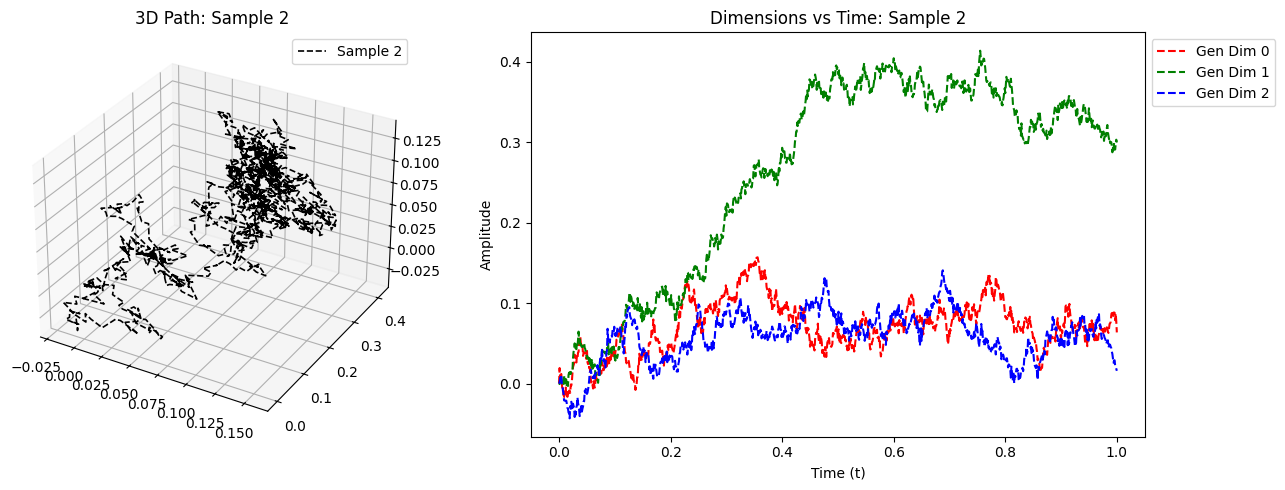

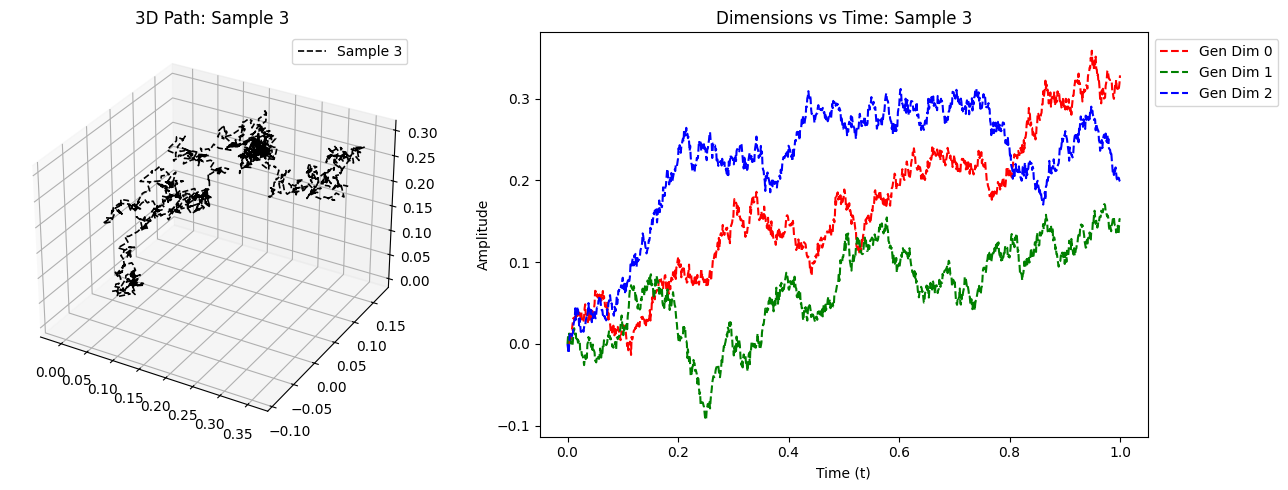

In [10]:
# --- [7. Plotting the first 3 samples] ---
for s in range(3):
    W_gen = all_W_gen[s]
    fig = plt.figure(figsize=(14, 5))

    # Left: 3D Trajectory
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot(W_gen[:,0], W_gen[:,1], W_gen[:,2], 'k--', linewidth=1.2, label=f'Sample {s+1}')
    ax1.set_title(f"3D Path: Sample {s+1}")
    ax1.legend()

    # Right: Dimensions vs Time
    ax2 = fig.add_subplot(122)
    colors = ['r', 'g', 'b']
    for i in range(d):
        ax2.plot(t_path, W_gen[:, i], color=colors[i], linestyle='--', label=f'Gen Dim {i}')

    ax2.set_title(f"Dimensions vs Time: Sample {s+1}")
    ax2.set_xlabel("Time (t)")
    ax2.set_ylabel("Amplitude")
    ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

In [11]:
# --- [8. Statistical Evaluation (Mean of 100 samples)] ---

def evaluate_gen_statistics(W_batch, dt):
    # 1. Mean of paths (should be near 0)
    overall_mean = np.mean(W_batch)
    
    # 2. Increments
    increments = np.diff(W_batch, axis=1)
    
    # 3. Quadratic Variation: Sum of squared increments per path, per dimension
    qv_per_path_dim = np.sum(increments**2, axis=1) 
    mean_qv = np.mean(qv_per_path_dim)
    
    # 4. Increment Stats
    mean_inc = np.mean(increments)
    var_inc = np.var(increments)
    
    # 5. Autocorrelation
    acfs = []
    for s in range(W_batch.shape[0]):
        for dim in range(W_batch.shape[2]):
            rho = np.corrcoef(increments[s, :-1, dim], increments[s, 1:, dim])[0, 1]
            acfs.append(rho)
    mean_acf = np.mean(acfs)

    print("-" * 30)
    print(f"STATISTICS OVER {W_batch.shape[0]} SAMPLES")
    print("-" * 30)
    print(f"Path Mean:          {overall_mean:.5f} ")
    print(f"Quadratic Variation: {mean_qv:.5f}")
    print(f"Increment Mean:     {mean_inc:.5f}")
    print(f"Increment Variance: {var_inc:.5f}")
    print(f"Avg Autocorr (Lag1): {mean_acf:.5f}")
    print("-" * 30)

# --- [8. Ground Truth Evaluation: 100 Original OU Paths] ---

def get_original_ou_stats(n_samples, n_points, d, dt, T_bm, theta, mu, sigma):
    W_orig_paths = np.zeros((n_samples, n_points + 1, d))
    current_x = np.zeros((n_samples, d)) 

    for t_step in range(n_points):
        # Brownian noise
        dW = np.random.normal(0, np.sqrt(dt), size=(n_samples, d))
        # OU SDE step: dx = theta * (mu - x) * dt + sigma * dW
        dx = theta * (mu - current_x) * dt + sigma * dW
        current_x += dx
        W_orig_paths[:, t_step + 1, :] = current_x
    
    print("-" * 30)
    print(f"GROUND TRUTH STATS ({n_samples} REAL OU PATHS)")
    evaluate_gen_statistics(W_orig_paths, dt)


get_original_ou_stats(100, N_bm, d, dt, T_bm, theta_ou, mu_ou, sigma_ou)
evaluate_gen_statistics(all_W_gen, dt)

------------------------------
GROUND TRUTH STATS (100 REAL OU PATHS)
------------------------------
STATISTICS OVER 100 SAMPLES
------------------------------
Path Mean:          0.10188 
Quadratic Variation: 0.04014
Increment Mean:     0.00017
Increment Variance: 0.00004
Avg Autocorr (Lag1): 0.00204
------------------------------
------------------------------
STATISTICS OVER 100 SAMPLES
------------------------------
Path Mean:          0.09017 
Quadratic Variation: 0.04012
Increment Mean:     0.00015
Increment Variance: 0.00004
Avg Autocorr (Lag1): -0.22251
------------------------------
